## Data observation
**non-standard file format**

`*.ag` is not standard file format (like `*.csv`). However, the files contain tab-separated values

**Data fragmentation and invalid files**
Data is fragmented in multiple files in multiple directories. Each valid file contains Timestamp, measured value and instrument health data. alongside files with measurement data, there are also log files.

**Inconsistent files structure** 
File header is in some cases comma-separated and in other cases tab separated

```
Time	CO(ppm)	p_sample(in-hg-a)	f_sample(ccm)	co_meas(mV)	co_ref(mV)	mr_ratio	t_bench(C)	t_wheel(C)	t_oven(C)	t_box(C)
```
vs.
```
Time,CO(ppm),p_sample(in-hg-a),f_sample(ccm),co_meas(mV),co_ref(mV),mr_ratio,t_bench(C),t_wheel(C),t_oven(C),t_box(C)
```

**Invalid timestamps**

Example on the 2nd line (`1.179`)
Example:
```
231129165004	1.179	48.0	62.0	46.0	40.8	0.404	25.5	1515.0	3267.9	2759.3	
1.179	25.5	1512.0	3267.8	2758.3	1.179	48.0	62.7	46.0	
231129165024	40.8	0.405	25.5	1514.0	3271.1	2761.3	1.179	48.0	61.8	46.0
```

**Corrupted files**

invalid characters ath the end of some files - manually corrected

Example files with corrupted content:
- `/Tvarminne/Trace_gases/CO/2025/CO_tele_250507.ag`
- `/Tvarminne/Trace_gases/CO/2025/CO_tele_250721.ag`

**Invalid recods** 

In file `/Tvarminne/Trace_gases/CO/2025/CO_tele_251110.ag`

```
251110050800	0.059	29.0	1687.0	4225.5	3555.9	1.18	47.9	62.0	46.0	40.8	
251110050820	nan	nan	nan	nan	nan	nan	nan	nan	nan	nan	
251110050911	nan	nan	nan	nan	nan	nan	nan	nan	nan	nan	
251110051003	nan	nan	nan	nan	nan	nan	nan	nan	nan	nan	
251110051054	nan	nan	nan	nan	nan	nan	nan	nan	nan	nan	
251110051146	nan	nan	nan	nan	nan	nan	nan	nan	nan	nan	
```

Many files miss value in many records.

**Inconsistency in column order**

SO2 has values in third column insted of second

```
Time		flag		SO2		hiso2		intt		rctt		pgast		pres		smplfl		pmtv		lmpv		lmpi
221221000047	4C000000	0.20	0.00	28.0	44.8	0.00	723.6	0.476	-714.1	1015	90.00*	
221221000147	4C000000	0.20	0.00	28.0	44.8	0.00	723.6	0.476	-714.1	1015	90.00*	
221221000247	4C000000	0.20	0.00	28.0	44.8	0.00	723.6	0.476	-714.1	1015	90.00*	
```

# Loading data from files

Notebook-specific imports and constants

In [27]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from atmdp003.utils.config import TRACEGASES_RAW_DIR_PATH, PREPROCESSED_DIR_PATH


tracegases_raw_dir_path = TRACEGASES_RAW_DIR_PATH()
preprocessed_dir_path = PREPROCESSED_DIR_PATH()

DATA_MAP = {
    "CO": {
        "columns" : ["CO"],
        "n": [1],
        "units": ["ppm"],
    },
    "NO": {
        "columns" : ["NO", "NO2"],
        "n": [1, 2],
        "units": ["ppb", "ppb"]
    },
    "O3": {
        "columns" : ["O3"],
        "n": [1],
        "units": ["ppb"]
    },
    "SO2": {
        "columns" : ["SO2"],
        "n": [2],
        "units": ["ppb"]
    }
}

Load all data and combine it into single DataFrame `df`,
 negative values replaced with `NaN`

In [28]:
print(f"Raw data directory: {tracegases_raw_dir_path}")

dfs_gas = []

for gas, details in DATA_MAP.items():
    print(f"Processing {gas:<4}: {details}")
    path = Path(f"{tracegases_raw_dir_path}/{gas}")
    files_to_process = path.glob("*/*.ag")

    dfs = []
    for file in files_to_process:
        df = pd.read_csv(file, skiprows=1, header=None, sep=r'\s+', engine='python')
        keep_cols = [0] + details["n"]  # always keep the first column (timestamp) and the columns specified in details
        df = df.iloc[:, keep_cols]
        # setting column names
        df.columns = ["Time"] + details["columns"]
        # Converting first column (timestamps) to numeric, coercing errors to NaN
        df["Time"] = pd.to_numeric(df["Time"], errors='coerce')
        df["Time"] = pd.to_datetime(df["Time"], format='%y%m%d%H%M%S', errors='coerce')
        df.dropna(subset=["Time"], inplace=True)  # Drop rows where Time conversion failed
        for col in details["columns"]:
            df[col] = pd.to_numeric(df[col], errors='coerce')
            df[col] = df[col].mask(df[col] < 0, np.nan) 
        df = df.dropna(subset=details["columns"], how="all")
        # setting Time as index
        df.set_index("Time", inplace=True)
        df.columns = [f"{col}_{unit}" for col, unit in zip(details["columns"], details["units"])]
        # appending to list of dataframes for this gas
        dfs.append(df)
        
    df = pd.concat(dfs, ignore_index=False)
    duplicate_mask = df.index.duplicated(keep='first')
    print(f" - removing {duplicate_mask.sum()} rows - duplicate index")
    df = df[~duplicate_mask]
    # df = df.sort_index()
    dfs_gas.append(df)
    print(f" - df of {gas} has shape {df.shape}")
    print(f"  \\- index name: {df.index.name}, type: {df.index.dtype}")
    
df = pd.concat(dfs_gas, axis=1, sort=True)
print(f"combined df has shape {df.shape}")
print(df)

Raw data directory: /Users/rohal/projects/winterschool2026/ATMDP-003/local/trace_gases
Processing CO  : {'columns': ['CO'], 'n': [1], 'units': ['ppm']}
 - removing 3429 rows - duplicate index
 - df of CO has shape (7182693, 1)
  \- index name: Time, type: datetime64[us]
Processing NO  : {'columns': ['NO', 'NO2'], 'n': [1, 2], 'units': ['ppb', 'ppb']}
 - removing 0 rows - duplicate index
 - df of NO has shape (7411903, 2)
  \- index name: Time, type: datetime64[us]
Processing O3  : {'columns': ['O3'], 'n': [1], 'units': ['ppb']}
 - removing 491 rows - duplicate index
 - df of O3 has shape (8260087, 1)
  \- index name: Time, type: datetime64[us]
Processing SO2 : {'columns': ['SO2'], 'n': [2], 'units': ['ppb']}
 - removing 0 rows - duplicate index
 - df of SO2 has shape (842996, 1)
  \- index name: Time, type: datetime64[us]
combined df has shape (16445440, 5)
                     CO_ppm  NO_ppb  NO2_ppb  O3_ppb  SO2_ppb
Time                                                         
2022-1

Plot raw data

___________

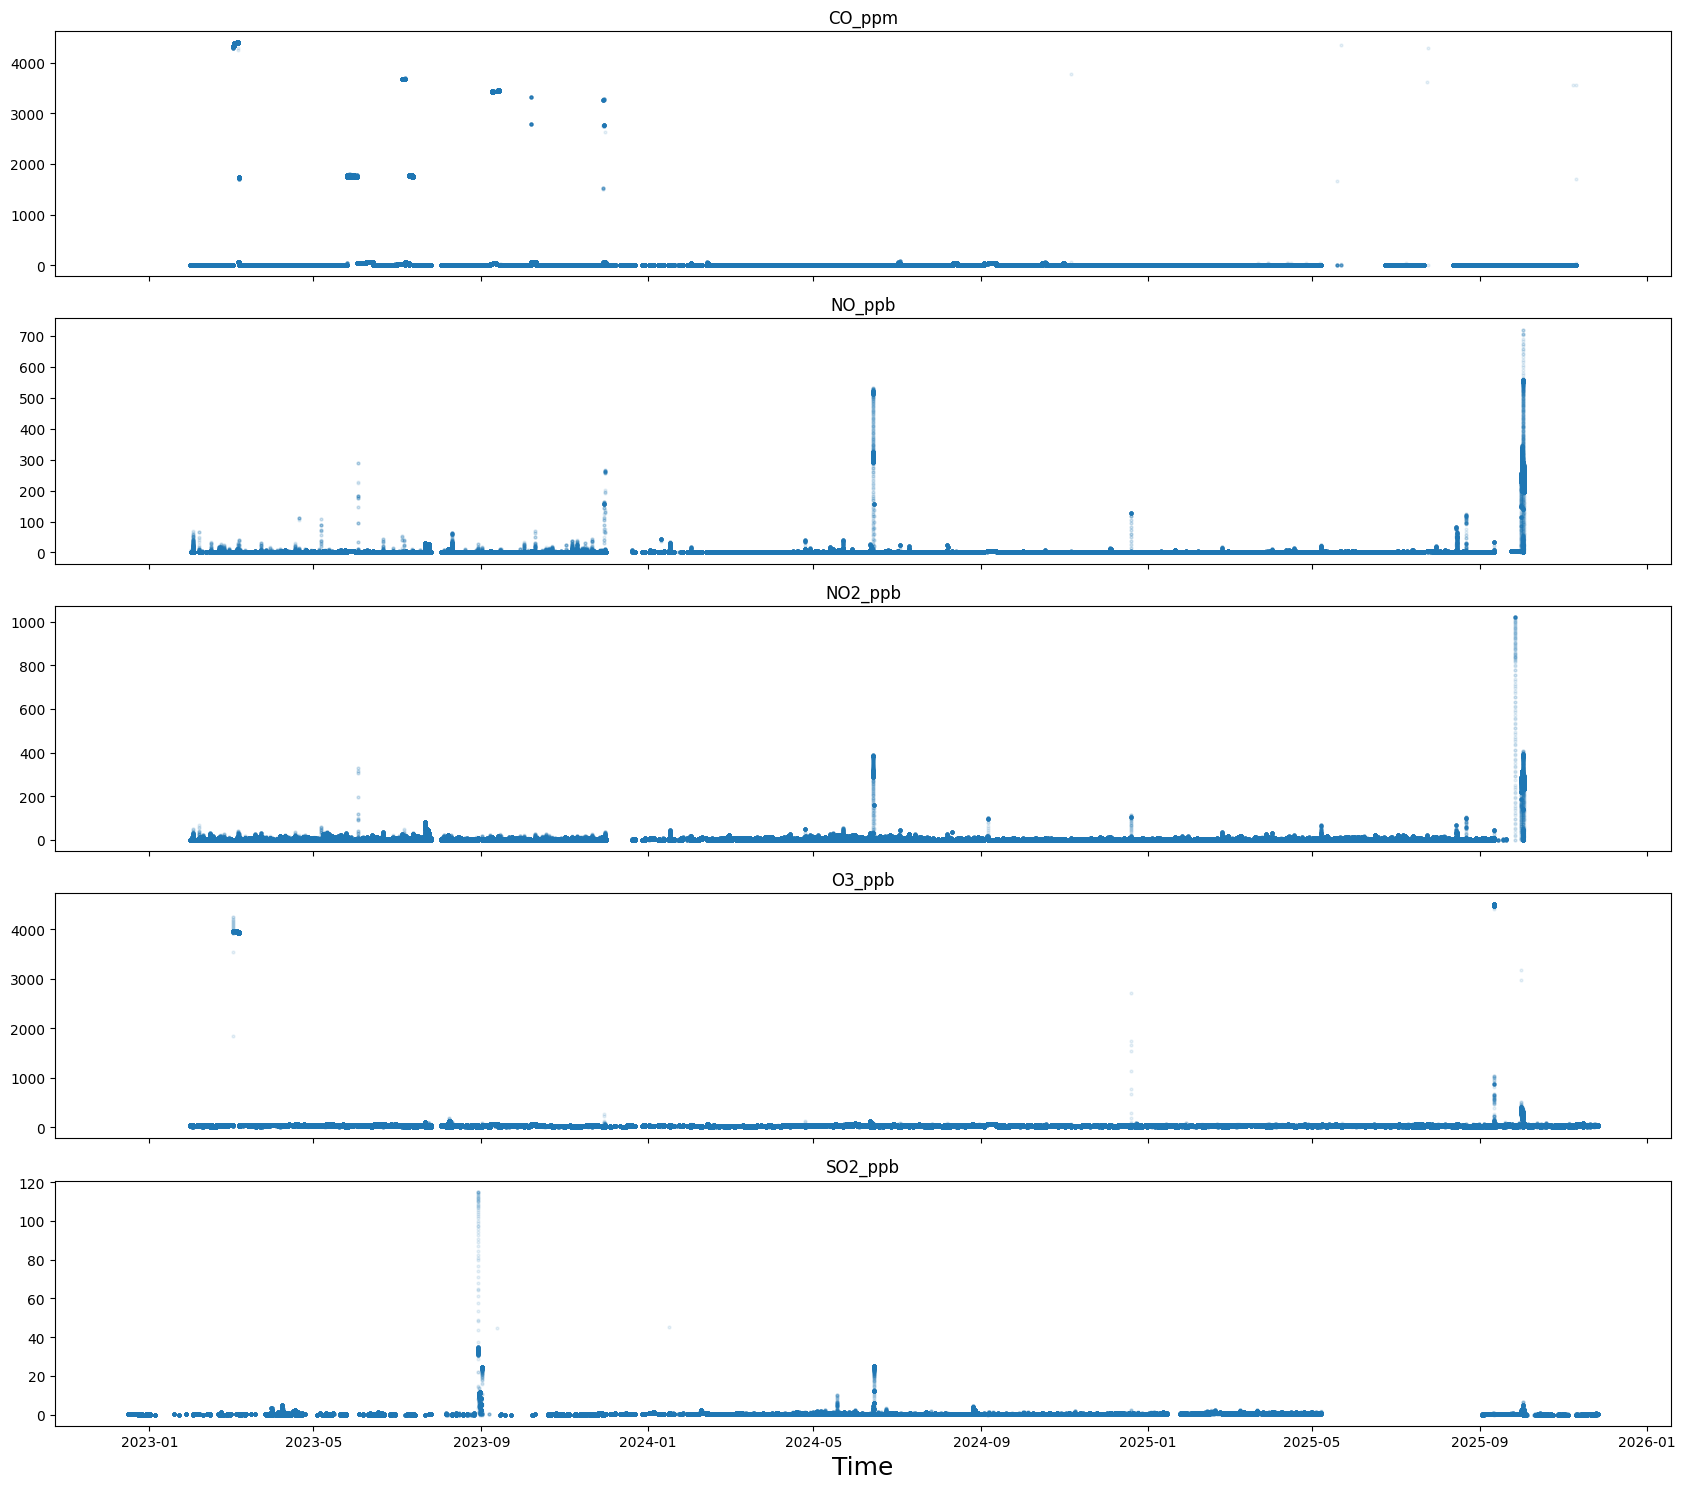

In [29]:
fig, axes = plt.subplots(
    df.shape[1],
    1,
    figsize=(17, 15),
    sharex=True,
)

for i, col in enumerate(df.columns):
    ax = axes[i]
    ax.plot(df.index, df[col], label=f"{col}", marker='o', markersize=2, linestyle='None', alpha=0.1)
    ax.set_title(col)
    
plt.xlabel("Time", fontsize=18)
plt.tight_layout()
plt.show()

Outliers, clear instrument malfunction

In [30]:
print(df.agg(['mean', 'median', 'std', 'min', 'max'])) # std is a sample std - devision by n-1 instead of N

             CO_ppm      NO_ppb      NO2_ppb       O3_ppb     SO2_ppb
mean      59.756980    1.632724     2.284940    49.250637    0.409501
median     0.101000    0.094000     0.820000    32.600000    0.340000
std      418.359496   16.952535    13.379734   257.202387    1.205027
min       -0.000000   -0.000000    -0.000000    -0.000000   -0.000000
max     4406.100000  719.812000  1020.983000  4503.000000  115.000000


https://acp.copernicus.org/articles/25/2443/2025/index.html?utm_source=chatgpt.com
https://acp.copernicus.org/articles/26/489/2026/index.html?utm_source=chatgpt.com
setting max values based on the articles above - interested in background levels, not spikes caused by i.e. ship combustion, ignoring gaps

In [31]:
MAX_VALUES = {
    # "CO_ppb": 100,
    "CO_ppm": 0.4,
    "NO_ppb": 1.3,
    "NO2_ppb": 2,
    "O3_ppb": 60,
    # "SO2_ppb": 5,
    "SO2_ppb": 1.5,
}

Rolling z-score - not considering gaps in data

In [32]:
window = 600
threshold = 2

for col in df.columns:
    unrealistic = df[col] > MAX_VALUES.get(col)
    print(f"Column: {col}, Unrealistic detected: {unrealistic.sum()}")
    df.loc[unrealistic, col] = np.nan
    df[col] = df[col].mask(df[col] > MAX_VALUES[col] , np.nan) 
    rolling_mean = df[col].rolling(window=window, center=True).mean()
    rolling_std = df[col].rolling(window=window, center=True).std()
    z_score = (df[col] - rolling_mean) / rolling_std
    outliers = z_score.abs() > threshold
    print(f"Column: {col}, Outliers detected: {outliers.sum()}")
    df.loc[outliers, col] = np.nan

print(df.agg(['mean', 'median', 'std', 'min', 'max']))

Column: CO_ppm, Unrealistic detected: 871570
Column: CO_ppm, Outliers detected: 5526
Column: NO_ppb, Unrealistic detected: 528231
Column: NO_ppb, Outliers detected: 219
Column: NO2_ppb, Unrealistic detected: 1846543
Column: NO2_ppb, Outliers detected: 1477
Column: O3_ppb, Unrealistic detected: 79716
Column: O3_ppb, Outliers detected: 3564
Column: SO2_ppb, Unrealistic detected: 7668
Column: SO2_ppb, Outliers detected: 433
          CO_ppm   NO_ppb   NO2_ppb     O3_ppb   SO2_ppb
mean    0.107633  0.18347  0.675088  31.966718  0.351023
median  0.097000  0.06900  0.534000  32.500000  0.330000
std     0.068076  0.25902  0.516740  10.265948  0.203206
min    -0.000000 -0.00000 -0.000000  -0.000000 -0.000000
max     0.400000  1.30000  2.000000  60.000000  1.500000


Hourly median

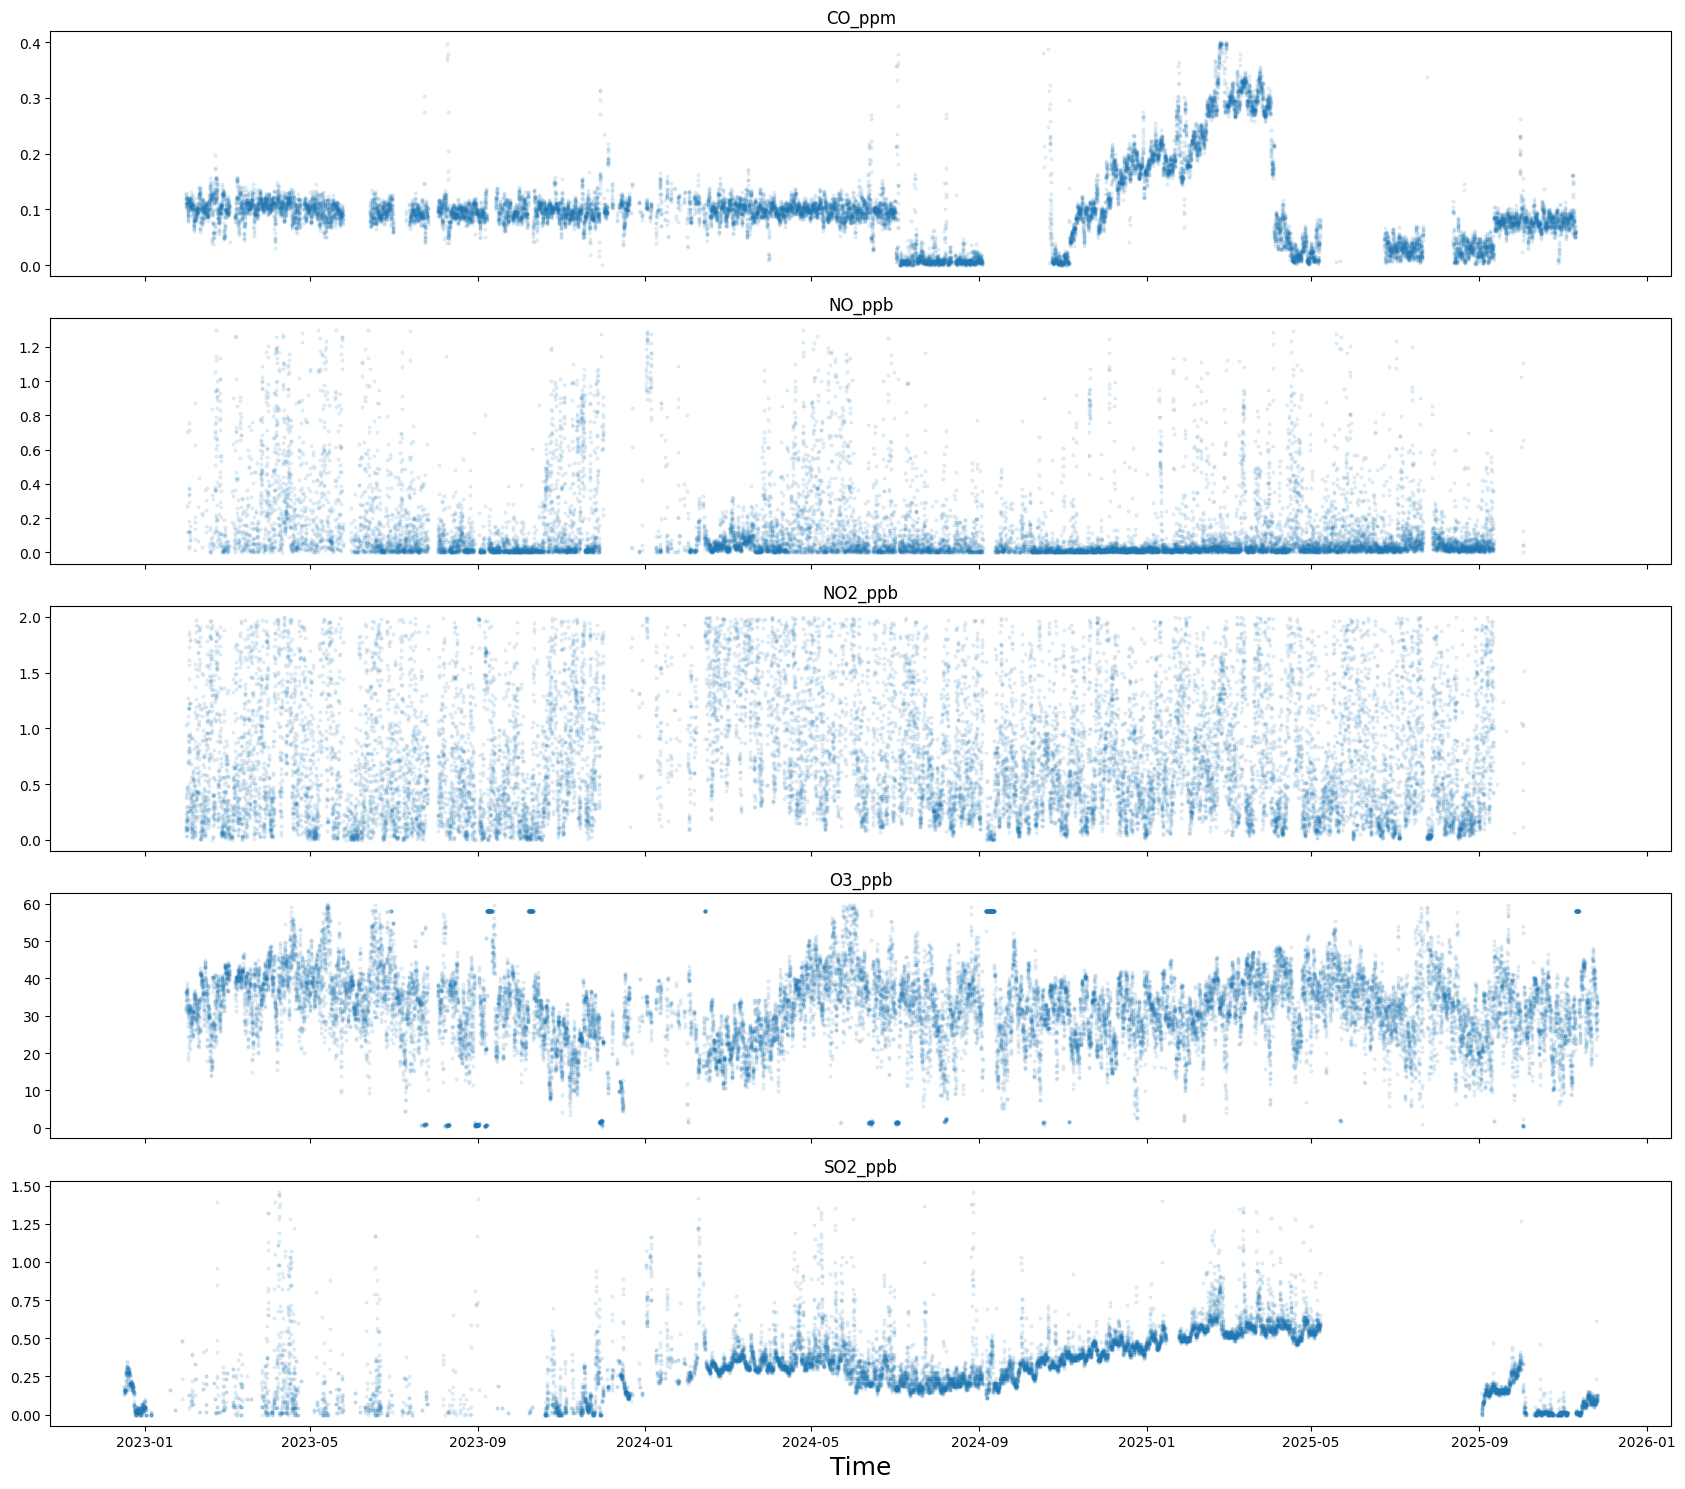

In [33]:
df_h = df.resample("h").median()

fig, axes = plt.subplots(
    df_h.shape[1],
    1,
    figsize=(17, 15),
    sharex=True,
)

for i, col in enumerate(df_h.columns):
    ax = axes[i]
    ax.plot(df_h.index, df_h[col], label=f"{col}", marker='o', markersize=2, linestyle='None', alpha=0.1)
    ax.set_title(col)

plt.xlabel("Time", fontsize=18)
plt.tight_layout()
plt.show()

Save combined data in new csv file

In [34]:
df_h.to_csv(f"{preprocessed_dir_path}/tracegasses.csv", index=True, date_format="%Y-%m-%d %H:%M:%S")

Prepare data for plotting

In [35]:
import numpy as np
import pandas as pd

print(df_h.shape)
print(df_h.columns)
print(df_h.head())





(25814, 5)
Index(['CO_ppm', 'NO_ppb', 'NO2_ppb', 'O3_ppb', 'SO2_ppb'], dtype='str')
                     CO_ppm  NO_ppb  NO2_ppb  O3_ppb  SO2_ppb
Time                                                         
2022-12-16 15:00:00     NaN     NaN      NaN     NaN     0.18
2022-12-16 16:00:00     NaN     NaN      NaN     NaN     0.16
2022-12-16 17:00:00     NaN     NaN      NaN     NaN     0.14
2022-12-16 18:00:00     NaN     NaN      NaN     NaN     0.18
2022-12-16 19:00:00     NaN     NaN      NaN     NaN     0.13


In [36]:
# import numpy as np
# import matplotlib.pyplot as plt

# np.random.seed(42)

# # -----------------------------
# # Example nested data structure
# # -----------------------------
# # data[season][subgroup][measure] = array of observations

# data = {
#     'Spring': {
#         'A': [
#             np.random.normal(10, 2, 30),
#             np.random.normal(15, 2, 30),
#             np.random.normal(20, 2, 30),
#             np.random.normal(25, 2, 30),
#         ],
#         'B': [
#             np.random.normal(12, 2, 30),
#             np.random.normal(17, 2, 30),
#             np.random.normal(22, 2, 30),
#             np.random.normal(27, 2, 30),
#         ],
#         'C': [
#             np.random.normal(14, 2, 30),
#             np.random.normal(19, 2, 30),
#             np.random.normal(25, 2, 30),
#             np.random.normal(29, 2, 30),
#         ],
#         'D': [
#             np.random.normal(14, 2, 30),
#             np.random.normal(19, 2, 30),
#             np.random.normal(25, 2, 30),
#             np.random.normal(29, 2, 30),
#         ],
#         'E': [
#             np.random.normal(14, 2, 30),
#             np.random.normal(19, 2, 30),
#             np.random.normal(25, 2, 30),
#             np.random.normal(29, 2, 30),
#         ]
#     },
#     'Summer': {
#         'A': [
#             np.random.normal(14, 2, 30),
#             np.random.normal(18, 2, 30),
#             np.random.normal(24, 2, 30),
#             np.random.normal(28, 2, 30),
#         ],
#         'B': [
#             np.random.normal(16, 2, 30),
#             np.random.normal(20, 2, 30),
#             np.random.normal(26, 2, 30),
#             np.random.normal(30, 2, 30),
#         ],
#         'C': [
#             np.random.normal(14, 2, 30),
#             np.random.normal(19, 2, 30),
#             np.random.normal(25, 2, 30),
#             np.random.normal(29, 2, 30),
#         ],
#         'D': [
#             np.random.normal(14, 2, 30),
#             np.random.normal(19, 2, 30),
#             np.random.normal(25, 2, 30),
#             np.random.normal(29, 2, 30),
#         ],
#         'E': [
#             np.random.normal(14, 2, 30),
#             np.random.normal(19, 2, 30),
#             np.random.normal(25, 2, 30),
#             np.random.normal(29, 2, 30),
#         ]
#     },
#     'Autumn': {
#         'A': [
#             np.random.normal(9, 2, 30),
#             np.random.normal(13, 2, 30),
#             np.random.normal(18, 2, 30),
#             np.random.normal(23, 2, 30),
#         ],
#         'B': [
#             np.random.normal(11, 2, 30),
#             np.random.normal(15, 2, 30),
#             np.random.normal(20, 2, 30),
#             np.random.normal(25, 2, 30),
#         ],
#         'C': [
#             np.random.normal(14, 2, 30),
#             np.random.normal(19, 2, 30),
#             np.random.normal(25, 2, 30),
#             np.random.normal(29, 2, 30),
#         ],
#         'D': [
#             np.random.normal(14, 2, 30),
#             np.random.normal(19, 2, 30),
#             np.random.normal(25, 2, 30),
#             np.random.normal(29, 2, 30),
#         ],
#         'E': [
#             np.random.normal(14, 2, 30),
#             np.random.normal(19, 2, 30),
#             np.random.normal(25, 2, 30),
#             np.random.normal(29, 2, 30),
#         ]
#     },
#     'Winter': {
#         'A': [
#             np.random.normal(6, 2, 30),
#             np.random.normal(10, 2, 30),
#             np.random.normal(15, 2, 30),
#             np.random.normal(20, 2, 30),
#         ],
#         'B': [
#             np.random.normal(8, 2, 30),
#             np.random.normal(12, 2, 30),
#             np.random.normal(17, 2, 30),
#             np.random.normal(22, 2, 30),
#         ],
#         'C': [
#             np.random.normal(14, 2, 30),
#             np.random.normal(19, 2, 30),
#             np.random.normal(25, 2, 30),
#             np.random.normal(29, 2, 30),
#         ],
#         'D': [
#             np.random.normal(14, 2, 30),
#             np.random.normal(19, 2, 30),
#             np.random.normal(25, 2, 30),
#             np.random.normal(29, 2, 30),
#         ],
#         'E': [
#             np.random.normal(14, 2, 30),
#             np.random.normal(19, 2, 30),
#             np.random.normal(25, 2, 30),
#             np.random.normal(29, 2, 30),
#         ]
#     }
# }

# seasons = list(data.keys())
# subgroups = ['A', 'B', 'C', 'D', 'E']
# measure_names = ['M1', 'M2', 'M3', 'M4']

# # -----------------------------
# # Layout settings
# # -----------------------------
# season_centers = np.arange(len(seasons)) * 4.0    # spacing between main groups
# subgroup_offsets = np.linspace(-0.3, 0.3, 5)                    # A and B within each season
# measure_offsets = np.linspace(-1.5, 1.5, 4)         # 4 measures within each subgroup

# colors = ['skyblue', 'lightgreen', 'salmon', 'plum']

# fig, ax = plt.subplots(figsize=(14, 7))

# # -----------------------------
# # Plot boxplots
# # -----------------------------
# for m, measure in enumerate(measure_names):
#     all_data = []
#     all_positions = []

#     for s, season in enumerate(seasons):
#         for g, subgroup in enumerate(subgroups):
#             all_data.append(data[season][subgroup][m])
#             pos = season_centers[s] + subgroup_offsets[g] + measure_offsets[m]
#             all_positions.append(pos)

#     bp = ax.boxplot(
#         all_data,
#         positions=all_positions,
#         widths=0.15,
#         patch_artist=True,
#         manage_ticks=False
#     )


In [37]:

#     for box in bp['boxes']:
#         box.set(facecolor=colors[m], alpha=0.7)

# # -----------------------------
# # Main x-axis labels (Seasons)
# # -----------------------------
# ax.set_xticks(season_centers)
# ax.set_xticklabels(seasons, fontsize=12)

# # -----------------------------
# # Add subgroup labels manually
# # -----------------------------
# for s, season in enumerate(seasons):
#     for g, subgroup in enumerate(subgroups):
#         subgroup_center = season_centers[s] + subgroup_offsets[g]
#         ax.text(
#             subgroup_center, 
#             ax.get_ylim()[0] - 1.5,   # move below axis
#             subgroup,
#             ha='center',
#             va='top',
#             fontsize=10
#         )

# # -----------------------------
# # Legend
# # -----------------------------
# for i, color in enumerate(colors):
#     ax.plot([], c=color, label=measure_names[i])

# ax.legend(title='Measures')
# ax.set_title('Grouped Boxplot with Subgroups')
# ax.set_xlabel('Season')
# ax.set_ylabel('Value')

# plt.tight_layout()
# plt.show()